# Import data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
dataset = pd.read_csv('gdrive/My Drive/Predicting Air Quality in Cities around the World/final_dataset2.csv')

In [ ]:
# info anzeigen
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1139 entries, 0 to 1138
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   City                          1139 non-null   object 
 1   Country                       1139 non-null   object 
 2   Country_Code                  1139 non-null   object 
 3   Year                          1139 non-null   int64  
 4   Month                         1139 non-null   int64  
 5   PM25                          1139 non-null   object 
 6   Latitude                      1139 non-null   object 
 7   Longitude                     1139 non-null   object 
 8   Elevation                     1139 non-null   int64  
 9   is_coast                      1139 non-null   int64  
 10  tavg                          1139 non-null   float64
 11  tmin                          1139 non-null   float64
 12  tmax                          1139 non-null   float64
 13  prc

# Align point and comma

In [ ]:
# copy the original dataset
df = dataset.copy()
# alles als string
df = df.astype(str)
# print head
print(df.head(3).T)

                                          0              1              2
City                              Amsterdam      Amsterdam      Amsterdam
Country                         Netherlands    Netherlands    Netherlands
Country_Code                            NLD            NLD            NLD
Year                                   2024           2024           2024
Month                                     1              2              3
PM25                                   10,2            8,2           11,9
Latitude                         52,3730796     52,3730796     52,3730796
Longitude                         4,8924534      4,8924534      4,8924534
Elevation                                15             15             15
is_coast                                  1              1              1
tavg                                    4.3            8.1            9.3
tmin                                    1.9            5.7            6.4
tmax                                  

In [ ]:
# clean area column
df['Area (square km)'] = df['Area (square km)'].astype(str).str.replace(',', '', regex=False)

def comma_to_float(s):
    if pd.isna(s): return None
    return float(str(s).replace(',', '.'))

def dot_thousand_to_int(s):
    if pd.isna(s): return None
    return int(str(s).replace('.', ''))

# Spalten mit deutschem Dezimalformat:
cols_comma_float = ['PM25', 'Latitude', 'Longitude', 'meanNDVI', 'Clean in %', 'demand in TWh', 'Fossil in %', 'Population density', 'GDP_growth_2021-2023 in %', '% Primary Sector', '% Secondary Sector', '% Tertiary Sector', 'GDP_per_capita']  # ggf. ergänzen
for col in cols_comma_float:
    df[col] = df[col].apply(comma_to_float)

# Spalten mit Punkt als Tausendertrennzeichen:
cols_dot_thousand = ['Population']  # ggf. ergänzen
for col in cols_dot_thousand:
    df[col] = df[col].apply(dot_thousand_to_int)

# Spalten, die schon korrektes englisches Format haben:
cols_float_standard = ['tavg', 'tmin', 'tmax', 'prcp', 'wspd', 'pres', 'num_large_airport', 'num_medium_airport', 'num_small_airport', 'num_total_airports', 'Num_PublicTransportStops', 'monthly_congestion_level [%]', 'yearly_congestion_level [%]']
for col in cols_float_standard:
    df[col] = df[col].astype(float)

# Spalten, die schon korrektes englisches Format haben in Int:
cols_int_standard = ['Year', 'Month', 'Elevation', 'is_coast', 'Area (square km)']
for col in cols_int_standard:
    df[col] = df[col].astype(int)

# Data scaling and rename columns

In [ ]:
# scale the data
df['% Primary Sector'] = df['% Primary Sector'] / 100
df['% Secondary Sector'] = df['% Secondary Sector'] / 100
df['% Tertiary Sector'] = df['% Tertiary Sector'] / 100
df['GDP_growth_2021-2023 in %'] = df['GDP_growth_2021-2023 in %'] / 100
df['monthly_congestion_level [%]'] = df['monthly_congestion_level [%]'] / 100
df['yearly_congestion_level [%]'] = df['yearly_congestion_level [%]'] / 100
df['Clean in %'] = df['Clean in %'] / 100
df['Fossil in %'] = df['Fossil in %'] / 100

In [ ]:
# rename the columns
df = df.rename(columns={'City': 'city',
                   'Country': 'country',
                   'Country_Code': 'country_code',
                   'Year': 'year',
                   'Month': 'month',
                   'PM25': 'pm25',
                   'Latitude': 'latitude',
                   'Longitude': 'longitude',
                   'Elevation': 'elevation',
                   'is_coast': 'is_coast',
                   'tavg': 'avg_temp',
                   'tmin': 'min_temp',
                   'tmax': 'max_temp',
                   'prcp': 'precipitation',
                   'wspd': 'wind_speed',
                   'pres': 'pressure',
                   'meanNDVI': 'ndvi',
                   'demand in TWh': 'electricity_demand',
                   'Clean in %': 'clean_energy',
                   'Fossil in %': 'fossil_energy',
                   'Population': 'population',
                   'Area (square km)': 'area',
                   'Population density': 'population_density',
                   'num_large_airport': 'large_airport',
                   'num_medium_airport': 'medium_airport',
                   'num_small_airport': 'small_airport',
                   'num_total_airport': 'total_airport',
                   'Num_PublicTransportStops': 'public_transport_stops',
                   'monthly_congestion_level [%]': 'monthly_congestion_level',
                   'yearly_congestion_level [%]': 'yearly_congestion_level',
                   'GDP_per_capita': 'gdp_per_capita',
                   'GDP_growth_2021-2023 in %': 'gdp_growth',
                   '% Primary Sector': 'primary_sector',
                   '% Secondary Sector': 'secondary_sector',
                   '% Tertiary Sector': 'tertiary_sector',
                   }
)

In [ ]:
# save dataset
df.to_csv('gdrive/My Drive/Predicting Air Quality in Cities around the World/dataset_scaled.csv', index=False)

# Exploratory Data Analysis

## Grundstatistiken

In [ ]:
# print the head of the dataframe
print(df.head())

        city      country country_code  year  month  pm25  latitude  \
0  Amsterdam  Netherlands          NLD  2024      1  10.2  52.37308   
1  Amsterdam  Netherlands          NLD  2024      2   8.2  52.37308   
2  Amsterdam  Netherlands          NLD  2024      3  11.9  52.37308   
3  Amsterdam  Netherlands          NLD  2024      4   5.8  52.37308   
4  Amsterdam  Netherlands          NLD  2024      5  11.2  52.37308   

   longitude  elevation  is_coast  ...  small_airport  num_total_airports  \
0   4.892453         15         1  ...            0.0                 1.0   
1   4.892453         15         1  ...            0.0                 1.0   
2   4.892453         15         1  ...            0.0                 1.0   
3   4.892453         15         1  ...            0.0                 1.0   
4   4.892453         15         1  ...            0.0                 1.0   

   public_transport_stops  monthly_congestion_level  yearly_congestion_level  \
0                  1342.0     

In [ ]:
# info anzeigen
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1139 entries, 0 to 1138
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   city                      1139 non-null   object 
 1   country                   1139 non-null   object 
 2   country_code              1139 non-null   object 
 3   year                      1139 non-null   int64  
 4   month                     1139 non-null   int64  
 5   pm25                      1139 non-null   float64
 6   latitude                  1139 non-null   float64
 7   longitude                 1139 non-null   float64
 8   elevation                 1139 non-null   int64  
 9   is_coast                  1139 non-null   int64  
 10  avg_temp                  1139 non-null   float64
 11  min_temp                  1139 non-null   float64
 12  max_temp                  1139 non-null   float64
 13  precipitation             1139 non-null   float64
 14  wind_spe

In [ ]:
# summary statistics
print(df.describe())

         year        month         pm25     latitude    longitude  \
count  1139.0  1139.000000  1139.000000  1139.000000  1139.000000   
mean   2024.0     6.495171    13.248025    27.012770     8.353285   
std       0.0     3.451232    14.844014    27.225398    80.048770   
min    2024.0     1.000000     2.000000   -41.288795  -123.113952   
25%    2024.0     3.500000     6.500000    18.788278   -73.569806   
50%    2024.0     6.000000     9.100000    35.676860    12.570072   
75%    2024.0     9.000000    14.550000    45.503182    72.869203   
max    2024.0    12.000000   224.000000    60.167488   174.777211   

         elevation     is_coast     avg_temp     min_temp     max_temp  ...  \
count  1139.000000  1139.000000  1139.000000  1139.000000  1139.000000  ...   
mean    301.913960     0.484636    17.316857    13.140650    22.041791  ...   
std     561.678184     0.499983     8.413243     8.200266     9.084035  ...   
min       0.000000     0.000000   -12.800000   -17.000000    -

In [ ]:
# show columns
print(df.columns)

Index(['city', 'country', 'country_code', 'year', 'month', 'pm25', 'latitude',
       'longitude', 'elevation', 'is_coast', 'avg_temp', 'min_temp',
       'max_temp', 'precipitation', 'wind_speed', 'pressure', 'ndvi',
       'clean_energy', 'electricity_demand', 'fossil_energy', 'population',
       'area', 'population_density', 'large_airport', 'medium_airport',
       'small_airport', 'num_total_airports', 'public_transport_stops',
       'monthly_congestion_level', 'yearly_congestion_level', 'gdp_per_capita',
       'gdp_growth', 'primary_sector', 'secondary_sector', 'tertiary_sector'],
      dtype='object')


In [ ]:
# are there missing values?
print(df.isnull().sum())

city                        0
country                     0
country_code                0
year                        0
month                       0
pm25                        0
latitude                    0
longitude                   0
elevation                   0
is_coast                    0
avg_temp                    0
min_temp                    0
max_temp                    0
precipitation               0
wind_speed                  0
pressure                    0
ndvi                        0
clean_energy                0
electricity_demand          0
fossil_energy               0
population                  0
area                        0
population_density          0
large_airport               0
medium_airport              0
small_airport               0
num_total_airports          0
public_transport_stops      0
monthly_congestion_level    0
yearly_congestion_level     0
gdp_per_capita              0
gdp_growth                  0
primary_sector              0
secondary_

## Untersuchung der Zielvariable

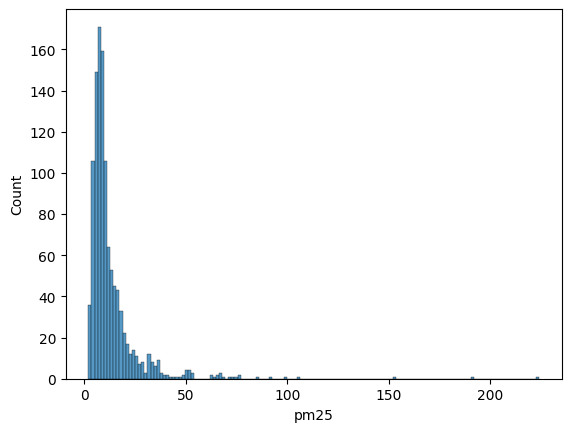

In [ ]:
# distribution of PM2.5 / histogram
sns.histplot(df['pm25'])
plt.show()

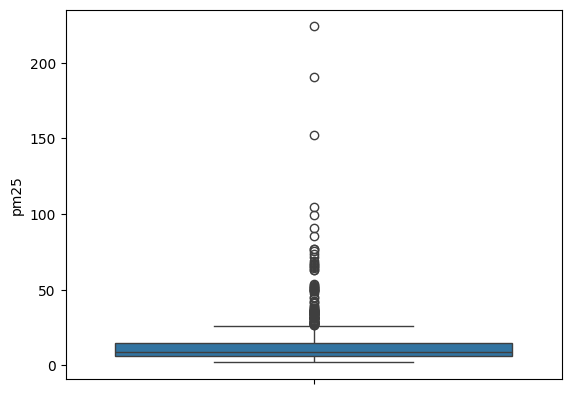

In [ ]:
# distribution of PM2.5 / boxplot
sns.boxplot(df['pm25'])
# plt.yscale('log')
plt.show()

In [ ]:
"""import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew

# --- 1. Verteilung der Zielvariable plotten ---
plt.figure(figsize=(6, 4))
plt.hist(y_train, bins=30, alpha=0.7, edgecolor='k')
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.title("Histogram of PM2.5 (y_train)")
plt.tight_layout()
plt.show()

# --- 2. Schiefe berechnen ---
skew_orig = skew(y_train)
print(f"Schiefe der Original-Zielvariable: {skew_orig:.3f}")

# --- 3. Log-Transformation ---
y_train_log = np.log1p(y_train)
plt.figure(figsize=(6, 4))
plt.hist(y_train_log, bins=30, alpha=0.7, edgecolor='k')
plt.xlabel("log(PM2.5 + 1)")
plt.ylabel("Frequency")
plt.title("Histogram of log(PM2.5 + 1)")
plt.tight_layout()
plt.show()
print(f"Schiefe nach log-Transformation: {skew(y_train_log):.3f}")

# --- 4. Sqrt-Transformation ---
y_train_sqrt = np.sqrt(y_train)
plt.figure(figsize=(6, 4))
plt.hist(y_train_sqrt, bins=30, alpha=0.7, edgecolor='k')
plt.xlabel("sqrt(PM2.5)")
plt.ylabel("Frequency")
plt.title("Histogram of sqrt(PM2.5)")
plt.tight_layout()
plt.show()
print(f"Schiefe nach sqrt-Transformation: {skew(y_train_sqrt):.3f}")"""


'import matplotlib.pyplot as plt\nimport numpy as np\nfrom scipy.stats import skew\n\n# --- 1. Verteilung der Zielvariable plotten ---\nplt.figure(figsize=(6, 4))\nplt.hist(y_train, bins=30, alpha=0.7, edgecolor=\'k\')\nplt.xlabel("PM2.5")\nplt.ylabel("Frequency")\nplt.title("Histogram of PM2.5 (y_train)")\nplt.tight_layout()\nplt.show()\n\n# --- 2. Schiefe berechnen ---\nskew_orig = skew(y_train)\nprint(f"Schiefe der Original-Zielvariable: {skew_orig:.3f}")\n\n# --- 3. Log-Transformation ---\ny_train_log = np.log1p(y_train)\nplt.figure(figsize=(6, 4))\nplt.hist(y_train_log, bins=30, alpha=0.7, edgecolor=\'k\')\nplt.xlabel("log(PM2.5 + 1)")\nplt.ylabel("Frequency")\nplt.title("Histogram of log(PM2.5 + 1)")\nplt.tight_layout()\nplt.show()\nprint(f"Schiefe nach log-Transformation: {skew(y_train_log):.3f}")\n\n# --- 4. Sqrt-Transformation ---\ny_train_sqrt = np.sqrt(y_train)\nplt.figure(figsize=(6, 4))\nplt.hist(y_train_sqrt, bins=30, alpha=0.7, edgecolor=\'k\')\nplt.xlabel("sqrt(PM2.5)")

Die Zielvariable ist rechtsschief und es gibt einige Outlier

## PM2.5 Untersuchung über Zeit

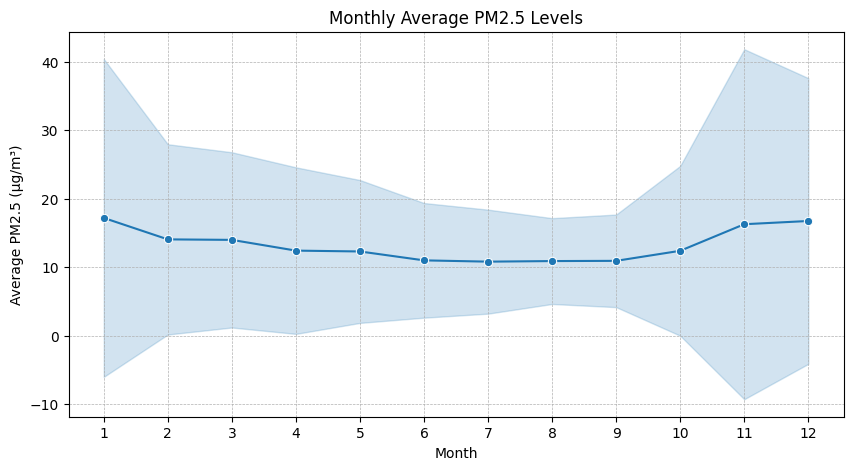

In [ ]:
# lineplot: PM2.5 over time
plt.figure(figsize=(10, 5))
sns.lineplot(x='month', y='pm25', data=df, estimator='mean', errorbar='sd', marker='o')
plt.title('Monthly Average PM2.5 Levels')
plt.xlabel('Month')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.xticks(range(1, 13))
plt.show()

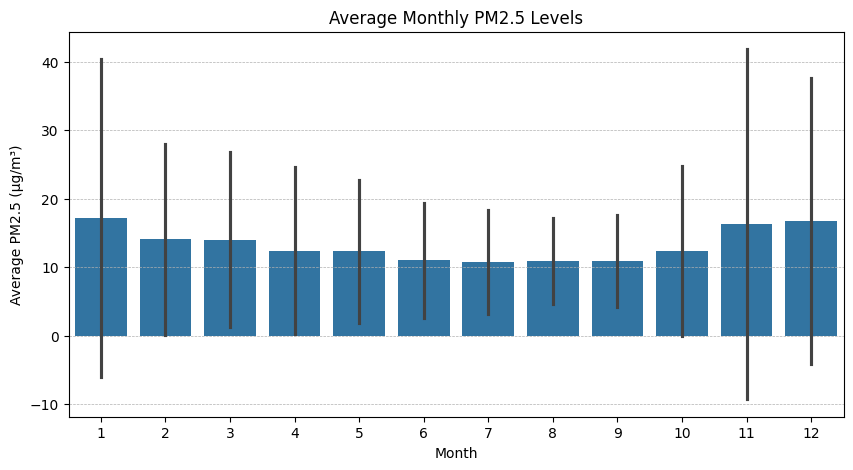

In [ ]:
# barplot: PM2.5 over time
plt.figure(figsize=(10, 5))
sns.barplot(x='month', y='pm25', data=df, estimator='mean', errorbar='sd')
plt.title('Average Monthly PM2.5 Levels')
plt.xlabel('Month')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.xticks(range(0, 12), [str(m) for m in range(1, 13)])  # Monatszahlen 1–12
plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
plt.show()

Beobachtungen: der durchschnittliche PM2.5 Wert ist im Winter höher als im Sommer. In den Sommermonaten sind die Werte recht stabil. Die Varianz nimmt in den Wintermonaten stark zu.

## Räumliche Untersuchung von PM2.5

In [ ]:
import plotly.express as px

# Monat als int sicherstellen
df['month'] = df['month'].astype(int)

fig = px.scatter_geo(
    df,
    lat='latitude',
    lon='longitude',
    color='pm25',
    size='pm25',
    size_max=40,
    animation_frame='month',
    projection='natural earth',
    color_continuous_scale='RdYlGn_r',
    range_color=[0, 80],
    title='PM2.5 Distribution by Month',
    hover_name='city',
    hover_data=['country', 'pm25']
)

fig.update_layout(
    geo=dict(
        showland=True,
        landcolor='#fdfdfd',     # fast weiß
        bgcolor='white',         # Kartenhintergrund
        showocean=True,
        oceancolor='#f9f9f9',    # fast weißes Wasser
        lakecolor='#f9f9f9',     # auch Seen aufhellen
        showframe=False
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1200,
    height=700
)

fig.show()


In [ ]:
# Karte mit den jährlichen Durchschnitten
# Mittelwert pro Stadt berechnen
city_avg = df.groupby(['city', 'latitude', 'longitude'], as_index=False)['pm25'].mean()
import plotly.express as px

fig = px.scatter_geo(
    city_avg,
    lat='latitude',
    lon='longitude',
    color='pm25',
    size='pm25',
    color_continuous_scale='RdYlGn_r',
    title='Average PM2.5 per City',
    hover_name='city',
    hover_data=['pm25'],
    projection='natural earth'
)

fig.update_layout(
    geo=dict(
        showland=True,
        landcolor='#fdfdfd',     # fast weiß
        bgcolor='white',         # Kartenhintergrund
        showocean=True,
        oceancolor='#f9f9f9',    # fast weißes Wasser
        lakecolor='#f9f9f9',     # auch Seen aufhellen
        showframe=False
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1200,
    height=700
)

fig.show()

Einzelne Regionen haben eine generell höhere Feinstaubbelastung. Man könnte Regionen zusammengefasst untersuchen (Europa, Asien, Amerika, ...)

In [ ]:
# Welche Stadt hat den höchsten monatlichen pm2.5 Wert?
print(df.loc[df['pm25'].idxmax()])


city                          New Delhi
country                           India
country_code                        IND
year                               2024
month                                11
pm25                              224.0
latitude                      28.643086
longitude                     77.219267
elevation                           211
is_coast                              0
avg_temp                           20.6
min_temp                           15.3
max_temp                           28.8
precipitation                       0.0
wind_speed                          1.8
pressure                         1014.3
ndvi                           0.052987
clean_energy                     0.2247
electricity_demand               133.51
fossil_energy                    0.7753
population                     31190000
area                               2344
population_density          13306.31399
large_airport                       1.0
medium_airport                      0.0


In [ ]:
# Welche Stadt hat den niedrigsten monatlichen PM2.5 Wert?
print(df.loc[df['pm25'].idxmin()])

city                           Auckland
country                     New Zealand
country_code                        NZL
year                               2024
month                                 3
pm25                                2.0
latitude                     -36.852095
longitude                     174.76318
elevation                           196
is_coast                              1
avg_temp                           16.6
min_temp                           12.9
max_temp                           20.1
precipitation                      85.1
wind_speed                         19.9
pressure                         1017.0
ndvi                           0.055653
clean_energy                     0.8168
electricity_demand                 3.33
fossil_energy                    0.1831
population                      1537000
area                                541
population_density           2841.03512
large_airport                       1.0
medium_airport                      0.0


## Korrelationen von PM2.5 mit den Features untersuchen

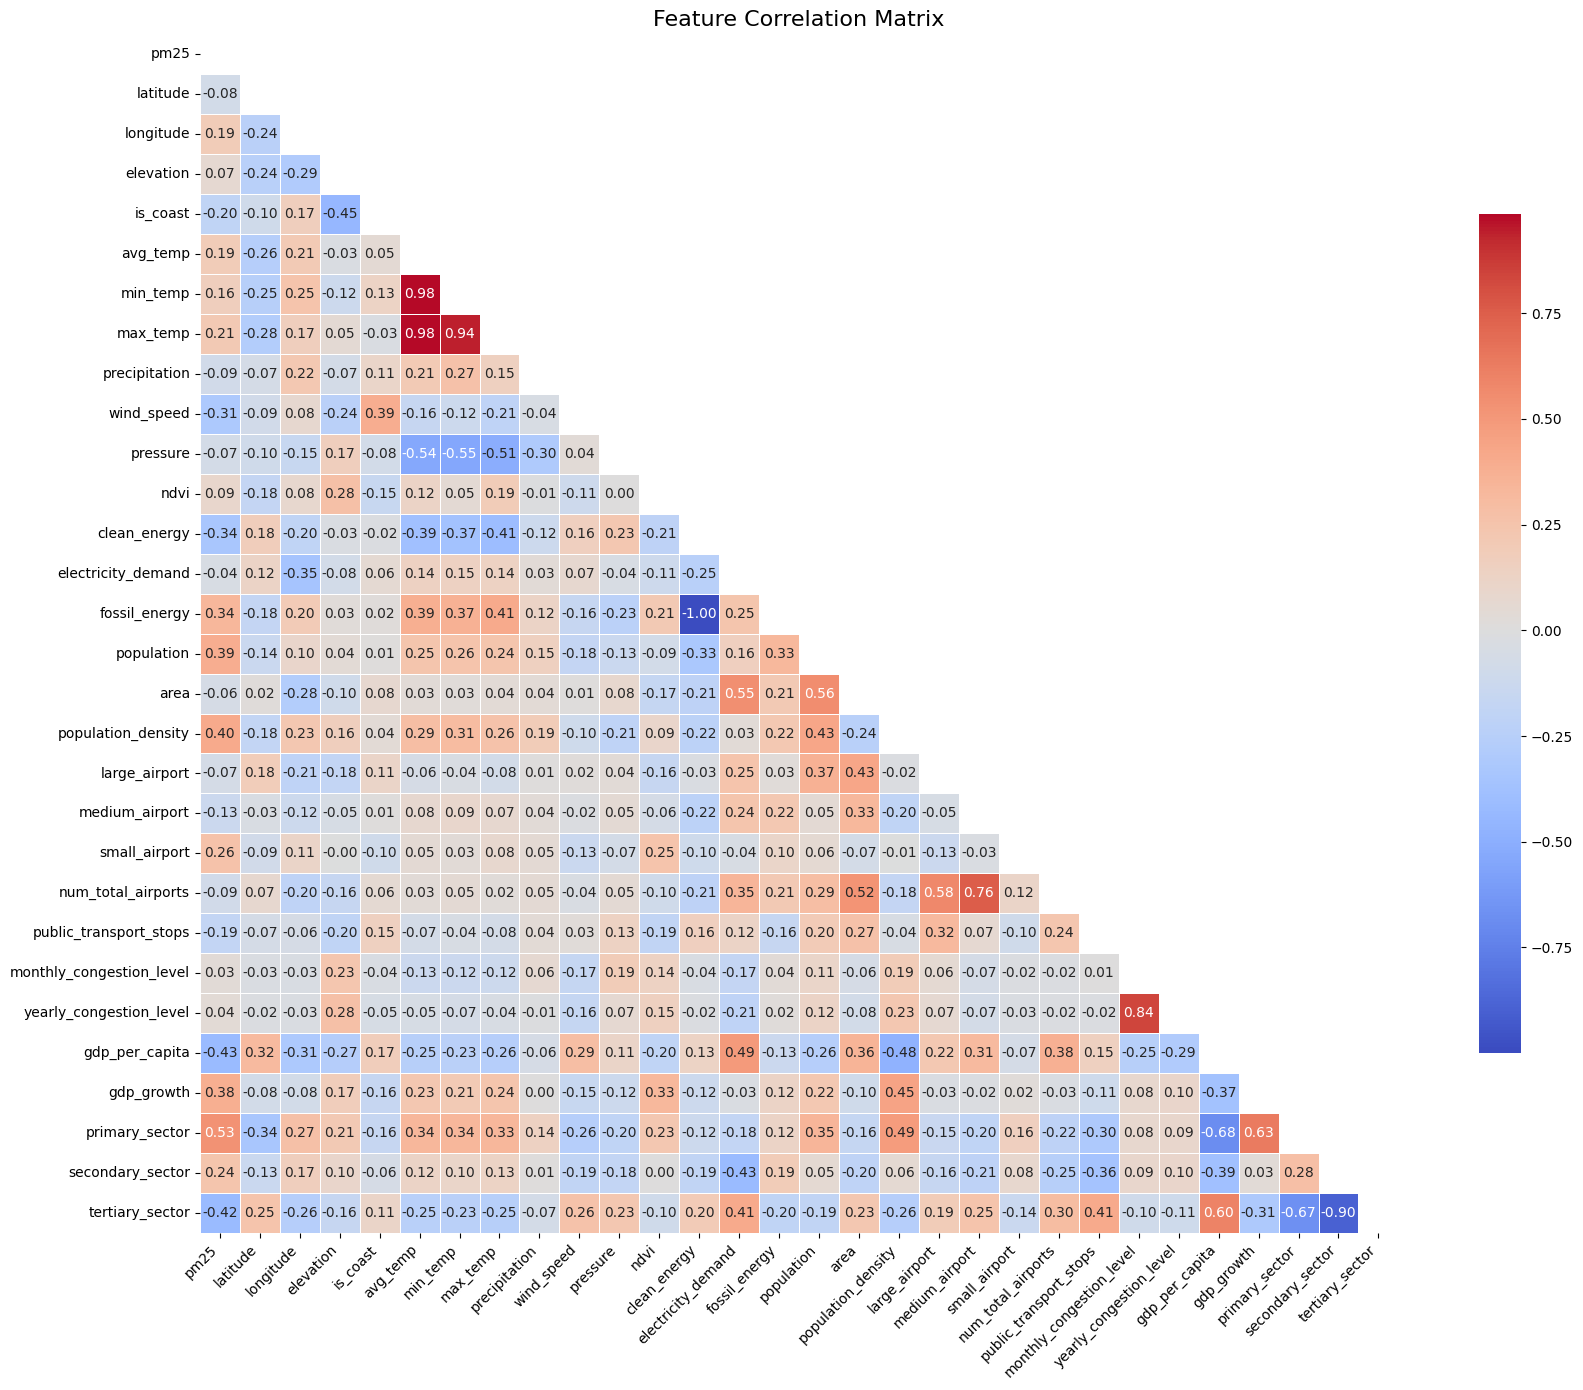

In [ ]:
# Heatmap zur Korrelation erstellen
# Korrelation berechnen
drop_cols = ['year', 'month']
corr_matrix = df.drop(columns=drop_cols).corr(numeric_only=True)

# Maske für obere Dreieck
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap größer darstellen
plt.figure(figsize=(18, 14))  # ⬅️ Größe anpassen

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.7,
    cbar_kws={'shrink': 0.7},
    square=True,
    annot_kws={"size": 10}  # ⬅️ Textgröße
)

plt.title('Feature Correlation Matrix', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

Einige Features korrelieren untereinander sehr stark.  
Maßnahme: einige der Features löschen

In [ ]:
# Features mit starker Collinearity löschen
df = df.drop(columns=['min_temp', 'max_temp', 'clean_energy', 'yearly_congestion_level', 'num_total_airports', 'primary_sector', 'secondary_sector'])
df.to_csv('gdrive/My Drive/Predicting Air Quality in Cities around the World/dataset_without_collinearity.csv', index=False)

/tmp/ipython-input-28-2007537802.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




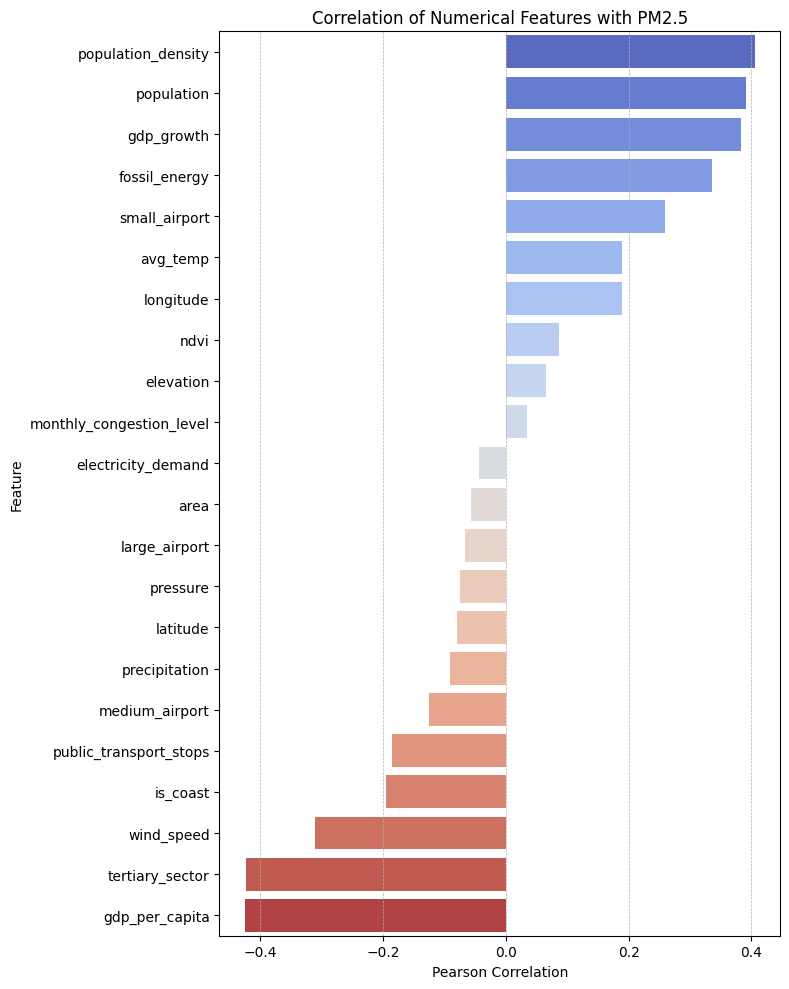

In [ ]:
# stärkste Korrelationen mit PM2.5
# Liste irrelevanter Spalten (nach deinem Ermessen)
drop_cols = ['year', 'month']

# Korrelation nur mit numerischen Variablen, ohne Drop-Spalten
corr = df.drop(columns=drop_cols).corr(numeric_only=True)

# Nur Korrelationen mit 'pm25'
pm25_corr = corr['pm25'].drop('pm25').sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, 10))
sns.barplot(x=pm25_corr.values, y=pm25_corr.index, palette='coolwarm')
plt.title('Correlation of Numerical Features with PM2.5')
plt.xlabel('Pearson Correlation')
plt.ylabel('Feature')
plt.grid(True, axis='x', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

1. Erkenntnis: Features korrelieren untereinander stark --> evtl. einige Features zusammenfassen oder löschen. Faustregel: Korrelation unter Features sollte unter +/- 0.7 sein
2. Erkenntnis: Manche Features korrelieren stark, andere fast gar nicht.

## Hypothesentest

GDP_per_capita korreliert stark negativ mit PM2.5 --> weitere Untersuchung

**Hypothese: Gibt es einen signifikanten Unterschied in den durchschnittlichen PM₂.₅-Konzentrationen zwischen armen und reichen Ländern?**

Nullhypothese: "Arme Länder" haben keine signifikante höhere PM2.5-Konzentration als "reiche Länder"

In [ ]:
# Definition "arme" vs. "reiche" Länder
print(df['gdp_per_capita'].describe())

count      1139.000000
mean      40907.134504
std       28726.939585
min        1952.300000
25%       13790.000000
50%       36551.400000
75%       64572.000000
max      103887.800000
Name: gdp_per_capita, dtype: float64


Wahl eines Schwellenwerts: weighted average GDP_per_capita von der World Bank: 13,169,60 --> Wir wählen das untere 25 % Quartil als Grenze für Arm. Länder, die über der Grenze liegen, gelten als reich

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

# Definiere die Gruppen anhand der GDP-Grenze
gdp_threshold = 13790
arme_laender = df[df["gdp_per_capita"] <= gdp_threshold]["pm25"].dropna()
reiche_laender = df[df["gdp_per_capita"] > gdp_threshold]["pm25"].dropna()

# Einseitiger t-Test: H1: mu_arm > mu_reich
t_stat, p_value = ttest_ind(arme_laender, reiche_laender, equal_var=False, alternative='greater')

# Ergebnisse ausgeben
print("t-statistic:", t_stat)
print("one-sided p-value:", p_value)

if p_value < 0.05:
    print("Ergebnis: Die armen Länder haben signifikant höhere PM2.5-Werte (H0 wird verworfen).")
else:
    print("Ergebnis: Kein signifikanter Unterschied (H0 kann nicht verworfen werden).")


t-statistic: 11.292328045788775
one-sided p-value: 1.932779811006133e-25
Ergebnis: Die armen Länder haben signifikant höhere PM2.5-Werte (H0 wird verworfen).


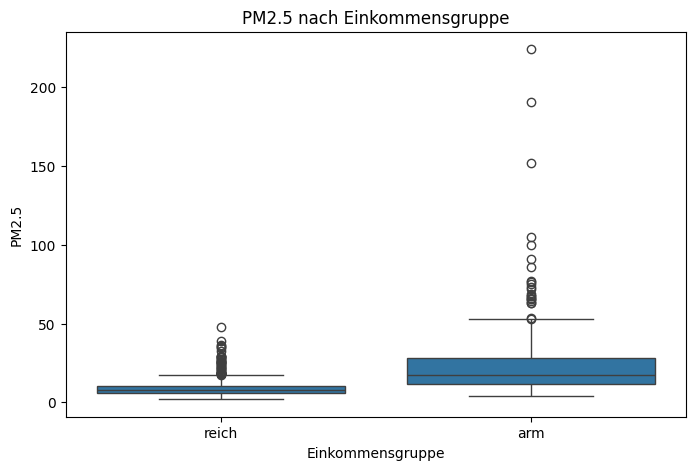

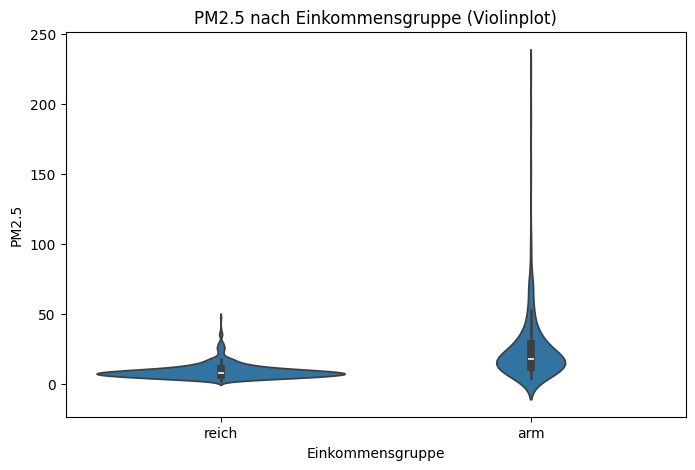

In [ ]:
# Hypothesentest plotten
import matplotlib.pyplot as plt
import seaborn as sns

# Neue Spalte für Gruppenzugehörigkeit
df["Einkommensgruppe"] = df["gdp_per_capita"].apply(lambda x: "arm" if x <= gdp_threshold else "reich")

plt.figure(figsize=(8, 5))
sns.boxplot(x="Einkommensgruppe", y="pm25", data=df)
plt.title("PM2.5 nach Einkommensgruppe")
plt.xlabel("Einkommensgruppe")
plt.ylabel("PM2.5")
plt.show()

# Optional: Violinplot
plt.figure(figsize=(8, 5))
sns.violinplot(x="Einkommensgruppe", y="pm25", data=df)
plt.title("PM2.5 nach Einkommensgruppe (Violinplot)")
plt.xlabel("Einkommensgruppe")
plt.ylabel("PM2.5")
plt.show()


Interpretation
1. Zentrale Tendenz und Lage
Arme Länder zeigen höhere Medianwerte und im Schnitt auch höhere PM2.5-Werte als reiche Länder. Das ist am „höher liegenden“ Kasten und Medianstrich im Boxplot gut erkennbar.
Reiche Länder haben niedrigere Werte, die Verteilung ist kompakter, der Median liegt tiefer.
2. Streuung & Ausreißer
Die Streuung (Breite der Box und Länge der „Whiskers“) ist bei armen Ländern viel größer.
Es gibt bei beiden Gruppen Ausreißer, aber bei armen Ländern reichen diese deutlich weiter nach oben (teilweise über 200 µg/m³), während bei reichen Ländern die meisten Werte deutlich darunter bleiben.
Der Violinplot bestätigt: Bei armen Ländern gibt es eine breite, nach oben offene Verteilung mit einigen extremen Werten, die auf sehr stark belastete Länder hindeuten.
3. Verteilungsform
Die Verteilung der PM2.5-Werte bei armen Ländern ist rechtsschief (langer „Schwanz“ nach oben). Das heißt: Einige Länder haben extrem hohe Belastungen, die den Durchschnitt stark erhöhen können.
Bei reichen Ländern sind die Werte kompakter, Ausreißer sind zwar da, aber in deutlich geringerer Anzahl und Höhe.
4. Fazit – in Bezug auf deine Hypothese
Visuell stützen die Plots die Alternativhypothese:
→ Arme Länder haben tendenziell höhere PM2.5-Werte als reiche Länder.
Die Unterschiede sind nicht nur im Median, sondern auch in der Verteilung sehr deutlich.
5. Statistischer Test
Die Plots machen es wahrscheinlich, dass ein einseitiger t-Test einen signifikanten Unterschied liefert (vorausgesetzt, die Verteilung ist nicht extrem abweichend von der Normalverteilung).
Du solltest zusätzlich noch die Mittelwerte, Standardabweichungen und das Ergebnis deines Tests berichten.

In [ ]:
# neue Spalte wieder löschen
df = df.drop(columns=['Einkommensgruppe'])

## Lineare Regression mit Statsmodel

In [ ]:
import statsmodels.api as sm

# Unerwünschte/kategorische Spalten entfernen
drop_cols = ['city', 'country', 'country_code', 'year', 'month']
df_clean = df.drop(columns=drop_cols)

# Features und Zielvariable festlegen
X = df_clean.drop('pm25', axis=1)
y = df_clean['pm25']

# Intercept-Spalte hinzufügen
X = sm.add_constant(X)

# Modell fitten
model = sm.OLS(y, X)
results = model.fit()

# Zusammenfassung anzeigen
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   pm25   R-squared:                       0.536
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     58.66
Date:                Sat, 05 Jul 2025   Prob (F-statistic):          1.10e-168
Time:                        11:09:53   Log-Likelihood:                -4250.6
No. Observations:                1139   AIC:                             8547.
Df Residuals:                    1116   BIC:                             8663.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

### Welche x-Variable ist statistisch signifikant?

In [ ]:
# Schwellenwert für Signifikanz
alpha = 0.05

# Alle Variablen mit p < 0.05
significant = results.pvalues[results.pvalues < alpha]
significant = significant.drop('const', errors='ignore')  # Intercept auslassen

print("\nSignificant variables (p < 0.05):")
for var in significant.index:
    coef = results.params[var]
    pval = results.pvalues[var]
    print(f"- {var}: Coefficient = {coef:.4f}, p-value = {pval:.4e}")


Significant variables (p < 0.05):
- longitude: Coefficient = 0.0129, p-value = 1.9053e-02
- elevation: Coefficient = -0.0032, p-value = 3.8221e-05
- is_coast: Coefficient = -2.8320, p-value = 2.2973e-04
- precipitation: Coefficient = -0.0224, p-value = 7.1435e-13
- wind_speed: Coefficient = -0.4321, p-value = 2.3905e-07
- pressure: Coefficient = 0.3760, p-value = 2.3508e-05
- ndvi: Coefficient = -48.0964, p-value = 3.7397e-05
- electricity_demand: Coefficient = 0.0137, p-value = 1.6570e-04
- fossil_energy: Coefficient = 12.0443, p-value = 9.4598e-15
- population: Coefficient = 0.0000, p-value = 1.0691e-14
- area: Coefficient = -0.0013, p-value = 9.0723e-05
- large_airport: Coefficient = -2.1222, p-value = 1.4044e-03
- medium_airport: Coefficient = -1.6851, p-value = 8.9138e-04
- small_airport: Coefficient = 12.5964, p-value = 9.9709e-14
- public_transport_stops: Coefficient = -0.0006, p-value = 2.9621e-03
- monthly_congestion_level: Coefficient = -9.9256, p-value = 1.2691e-02
- gdp_pe

In [ ]:
# --- Nicht-signifikante Variablen (p >= 0.05) ---
not_significant = results.pvalues[results.pvalues >= alpha]
not_significant = not_significant.drop('const', errors='ignore')

print("\nNot significant variables (p >= 0.05):")
for var in not_significant.index:
    coef = results.params[var]
    pval = results.pvalues[var]
    print(f"- {var}: Coefficient = {coef:.4f}, p-value = {pval:.4e}")


Not significant variables (p >= 0.05):
- latitude: Coefficient = 0.0227, p-value = 1.2850e-01
- avg_temp: Coefficient = -0.0841, p-value = 1.0192e-01
- population_density: Coefficient = 0.0002, p-value = 2.1717e-01


Nach Kontrolle für alle anderen Variablen lässt sich kein eindeutiger linearer Zusammenhang zwischen Temperatur / Bevölkerungsdichte und pm2.5 nachweisen

### Wie werden die Koeffizienten interpretiert?

In [ ]:
print("\nInterpretation of coefficients:")
for var in X.columns:
    if var == 'const':
        continue
    coef = results.params[var]
    if coef > 0:
        direction = "increases"
    else:
        direction = "decreases"
    print(f"- If {var} increases by 1 unit, the predicted pm25 {direction} by {abs(coef):.4f} (all else held constant).")


Interpretation of coefficients:
- If latitude increases by 1 unit, the predicted pm25 increases by 0.0227 (all else held constant).
- If longitude increases by 1 unit, the predicted pm25 increases by 0.0129 (all else held constant).
- If elevation increases by 1 unit, the predicted pm25 decreases by 0.0032 (all else held constant).
- If is_coast increases by 1 unit, the predicted pm25 decreases by 2.8320 (all else held constant).
- If avg_temp increases by 1 unit, the predicted pm25 decreases by 0.0841 (all else held constant).
- If precipitation increases by 1 unit, the predicted pm25 decreases by 0.0224 (all else held constant).
- If wind_speed increases by 1 unit, the predicted pm25 decreases by 0.4321 (all else held constant).
- If pressure increases by 1 unit, the predicted pm25 increases by 0.3760 (all else held constant).
- If ndvi increases by 1 unit, the predicted pm25 decreases by 48.0964 (all else held constant).
- If electricity_demand increases by 1 unit, the predicted pm

In [ ]:
# save data as csv
df.to_csv('gdrive/My Drive/Predicting Air Quality in Cities around the World/processed_data.csv', index=False)